# Veri Bilimi Eğitimi


## Veri Hikayeleştirme ve İş Yorumu

Amaç:
  1. Gerçek hayata benzeyen iş sorularını veri ile cevaplamak
  2. Analiz sonuçlarını tablo, grafik ve kısa iş yorumları ile sunmak

Adımlar:
  1. Hangi kategori hem yüksek gelir üretiyor hem de müşteri memnuniyeti açısından güçlü görünüyor?
  2. Hangi ödeme türleri daha yüksek ortalama sipariş tutarı üretiyor ve müşteri puanı açısından performans gösteriyor?
  3. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?
  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [ ]:
# 1. hangi kategori hem yüksek gelir hem de müşteri memnuniyetini yüksek sağlıyor
kategori_raporu = (
    df.groupby("kategori")
    .agg(
        toplam_gelir = ("toplam_tutar", "sum"),
        ortalama_musteri_puani = ("musteri_puani", "mean")
    )
    .round(2)
)

In [ ]:
kategori_raporu = kategori_raporu.sort_values(by = ["toplam_gelir"], ascending=[False])
kategori_raporu

,toplam_gelir,ortalama_musteri_puani
kategori,,
Elektronik,212930.29,4.24
Spor,189481.91,4.26
Kozmetik,147522.90,4.42
Ev Yaşam,142335.55,4.26
Kitap,114075.59,4.25
Ofis,47051.88,4.24


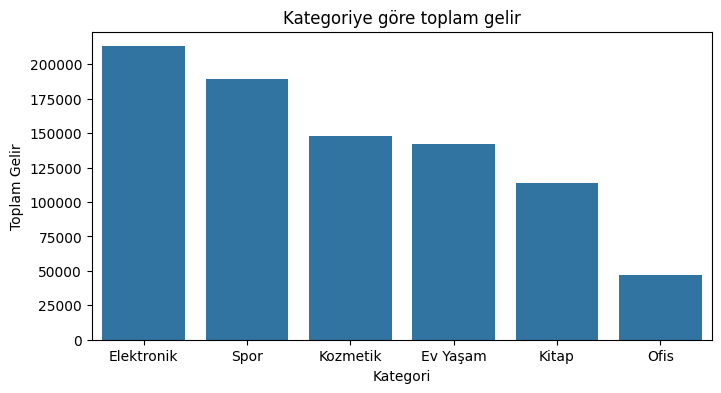

In [ ]:
# kategoriye göre toplam gelir
plt.figure(figsize = (8,4))
sns.barplot(data = kategori_raporu, x = "kategori", y = "toplam_gelir")
plt.title("Kategoriye göre toplam gelir")
plt.xlabel("Kategori")
plt.ylabel("Toplam Gelir")
plt.show()

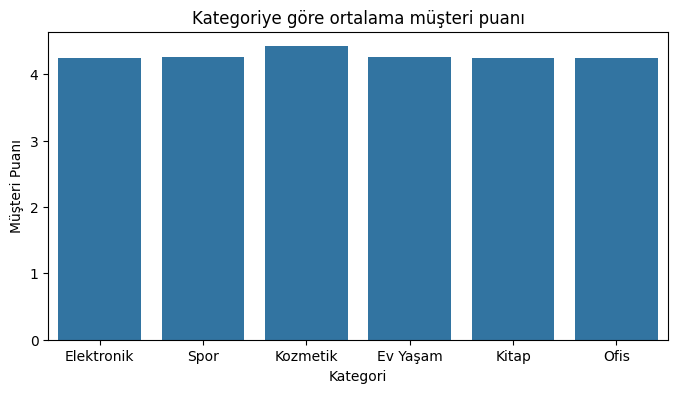

In [ ]:
# kategoriye göre ortalama musteri puani
plt.figure(figsize = (8,4))
sns.barplot(data = kategori_raporu, x = "kategori", y = "ortalama_musteri_puani")
plt.title("Kategoriye göre ortalama müşteri puanı")
plt.xlabel("Kategori")
plt.ylabel("Müşteri Puanı")
plt.show()

In [ ]:
# 2. hangi ödeme türleri daha yüksek ortalama sipariş tutarı üretiyor ve müşteri puanı açısından nasıl performans gösteriyor?
odeme_turu_raporu = (
    df.groupby("odeme_turu")
    .agg(
        ortalama_siparis_tutari = ("toplam_tutar", "mean"),
        ortalama_musteri_puani = ("musteri_puani", "mean")
    )
    .round(2)
    .sort_values("ortalama_siparis_tutari", ascending = False)
)
odeme_turu_raporu

,ortalama_siparis_tutari,ortalama_musteri_puani
odeme_turu,,
Dijital Cüzdan,849.09,4.27
Banka Kartı,846.22,4.24
Havale/EFT,836.89,4.15
Kredi Kartı,753.80,4.31
Kapıda Ödeme,609.03,4.38


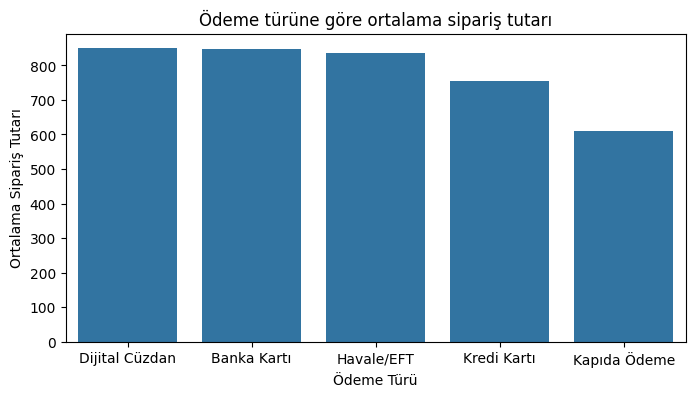

In [ ]:
# ödeme türüne göre ortalama sipariş tutarı
plt.figure(figsize = (8,4))
sns.barplot(data = odeme_turu_raporu, x = "odeme_turu", y = "ortalama_siparis_tutari")
plt.title("Ödeme türüne göre ortalama sipariş tutarı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Sipariş Tutarı")
plt.show()

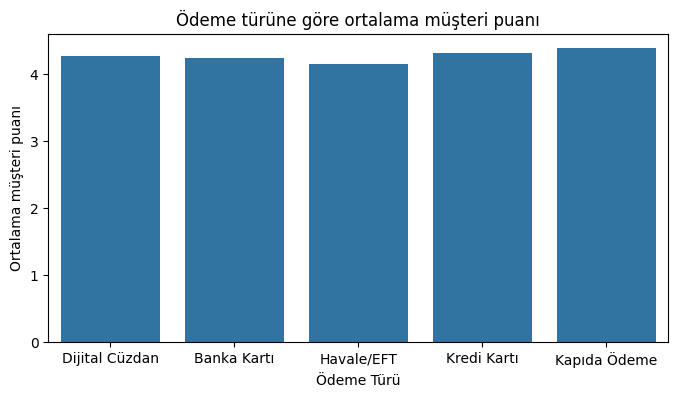

In [ ]:
# ödeme türüne göre ortalama müşteri puanı
plt.figure(figsize = (8,4))
sns.barplot(data = odeme_turu_raporu, x = "odeme_turu", y = "ortalama_musteri_puani")
plt.title("Ödeme türüne göre ortalama müşteri puanı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama müşteri puanı")
plt.show()

In [ ]:
# 3. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?
sehir_kategori_raporu = (
    df.groupby(["sehir", "kategori"])
    .agg(toplam_gelir = ("toplam_tutar", "sum"))
    .round(2)
    .sort_values(["toplam_gelir"], ascending = False)
)
sehir_kategori_raporu

toplam_gelir
sehir     kategori                
İstanbul  Elektronik      66731.92
          Spor            53391.34
          Ev Yaşam        34130.59
          Kozmetik        33167.28
          Kitap           27106.12
...                            ...
Eskişehir Ofis             1727.90
Kayseri   Elektronik       1715.61
Kocaeli   Ofis             1026.94
Kayseri   Ofis              868.53
Kocaeli   Elektronik        779.13

[84 rows x 1 columns]

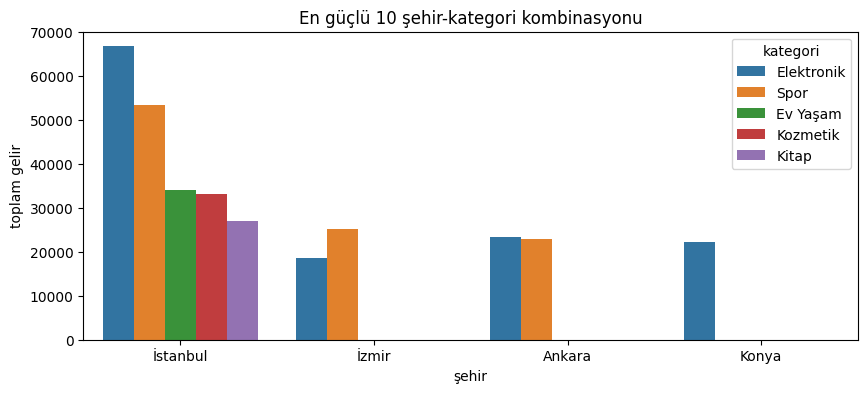

In [ ]:
# en güçlü 10 şehir kategori kombinasyonun görselleştir
en_guclu_10_kombinasyon = sehir_kategori_raporu.head(10).reset_index()
plt.figure(figsize = (10,4))
sns.barplot(
    data = en_guclu_10_kombinasyon,
    x = "sehir",
    y = "toplam_gelir",
    hue = "kategori"
)
plt.title("En güçlü 10 şehir-kategori kombinasyonu")
plt.xlabel("şehir")
plt.ylabel("toplam gelir")
plt.show()